In [1]:
import os

import h5ify
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import logsumexp

from util import plot_corner, plot_multiple
from util import merge_runs

from bilby.core.result import read_in_result

%load_ext autoreload
%autoreload 2

In [ ]:
post = read_in_result(f'{datadir}/bpl2p/log-sigma/var1/nlive/10000/run_result.hdf5')

In [ ]:
post.nested_samples['log_likelihood'].max()

In [ ]:
post.nested_samples['log_likelihood']

In [3]:
datadir = '../../data/inference/strong/multimass/noah'

In [28]:
unweighted_nlive10k = h5ify.load(f'{datadir}/bpl2p/log-sigma/var1/nlive/10000/posterior.h5')
nlive10k = h5ify.load(f'{datadir}/bpl2p/log-sigma/var1/nlive/10000/posterior.h5')

# sample to uniform in sigma prior
# p(sig | d) = p(d | sig)p(sig)
#            = p(d | sig)p(sig)p(lnsig) / p(lnsig)
#            = p(d | ln sig)p(lnsig) w   with w = p(sig) / p(lnsig)
# now, we know that a uniform prior in ln sigma is the same as a prior \propto 1 / sigma. i.e. p(ln sigma) \propto 1 / sigma.
# so p(sig | d) = p(d | ln sig) p(lnsig) / sig

log_sigmas = np.stack([nlive10k[f'log_sigma_{i}'] for i in range(1, 4)])
log_weights = -np.sum(log_sigmas, axis=0)

for k in list(nlive10k['samples'].keys()):
    nlive10k['samples'].pop(k)
    unweighted_nlive10k['samples'].pop(k)

for i in range(1, 4):
    nlive10k[f'sigma_{i}'] = np.exp(nlive10k[f'log_sigma_{i}'])
    nlive10k[f'log10_sigma_{i}'] = np.log10(nlive10k[f'sigma_{i}'])
    unweighted_nlive10k[f'sigma_{i}'] = np.exp(unweighted_nlive10k[f'log_sigma_{i}'])
    unweighted_nlive10k[f'log10_sigma_{i}'] = np.log10(unweighted_nlive10k[f'sigma_{i}'])

rng = np.random.default_rng(12413)
weights = np.exp(log_weights)
keep = weights > rng.uniform(0, max(weights), len(weights))

for k, v in nlive10k.items():
    if len(np.atleast_1d(v)) > 1:
        nlive10k[k] = v[keep]

In [96]:
# I think we need to combine the nested sampling weights together and reweight?

results = []
for seed in range(1701, 1711):
    rundir = f'{datadir}/bpl2p/sampling_seed/{seed}'
    r = read_in_result(f'{rundir}/run_result.hdf5')
    v = h5ify.load(f'{rundir}/posterior.h5')
    r.posterior['variance'] = v['variance']
    results.append(r)

In [107]:
_, merged = merge_runs(results, evidence_weight=True)
merged = {k : np.array(v) for k, v in merged.to_dict(orient='list').items()}

In [109]:
h5ify.save(f'{datadir}/bpl2p/sampling_seed/merged.h5', merged, mode='w')

In [22]:
for i in range(1, 4):
    merged[f'log_sigma_{i}'] = np.log(merged[f'sigma_{i}'])
    merged[f'log10_sigma_{i}'] = np.log10(merged[f'sigma_{i}'])

In [21]:
r_pt = h5ify.load(f'{datadir}/bpl2p/ptemcee-hybrid-var1/posterior.h5')

for k in list(r_pt['samples'].keys()):
    r_pt['samples'].pop(k)

for i in range(1, 4):
    r_pt[f'log_sigma_{i}'] = np.log(r_pt[f'sigma_{i}'])
    r_pt[f'log10_sigma_{i}'] = np.log10(r_pt[f'sigma_{i}'])

In [45]:
r_pt_5 = h5ify.load(f'{datadir}/bpl2p/ptemcee-hybrid-var5/posterior.h5')

for k in list(r_pt_5['samples'].keys()):
    r_pt_5['samples'].pop(k)

for i in range(1, 4):
    r_pt_5[f'log_sigma_{i}'] = np.log(r_pt_5[f'sigma_{i}'])
    r_pt_5[f'log10_sigma_{i}'] = np.log10(r_pt_5[f'sigma_{i}'])

Text(0.5, 0, '$\\xi$')

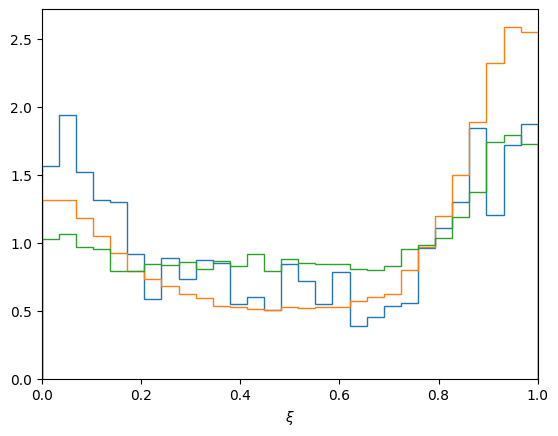

In [11]:
bins = np.linspace(0, 1, 30)
ks = dict(histtype='step', bins=bins, density=True)

fig, ax = plt.subplots()
ax.hist(
    r_pt['weight_a'],
    **ks
)
ax.hist(
    merged['weight_a'],
    **ks
)


ax.hist(
    nlive10k['samples']['weight_a'],
    #weights=np.exp(log_weights),
    **ks
);


ax.set_xlim(0, 1)
ax.set_xlabel(r'$\xi$')

about to plot with: ['weight_a', 'mu_1', 'mu_2', 'log10_sigma_1', 'log10_sigma_2', 'log_likelihood', 'variance']
about to plot with: ['weight_a', 'mu_1', 'mu_2', 'log10_sigma_1', 'log10_sigma_2', 'log_likelihood', 'variance']


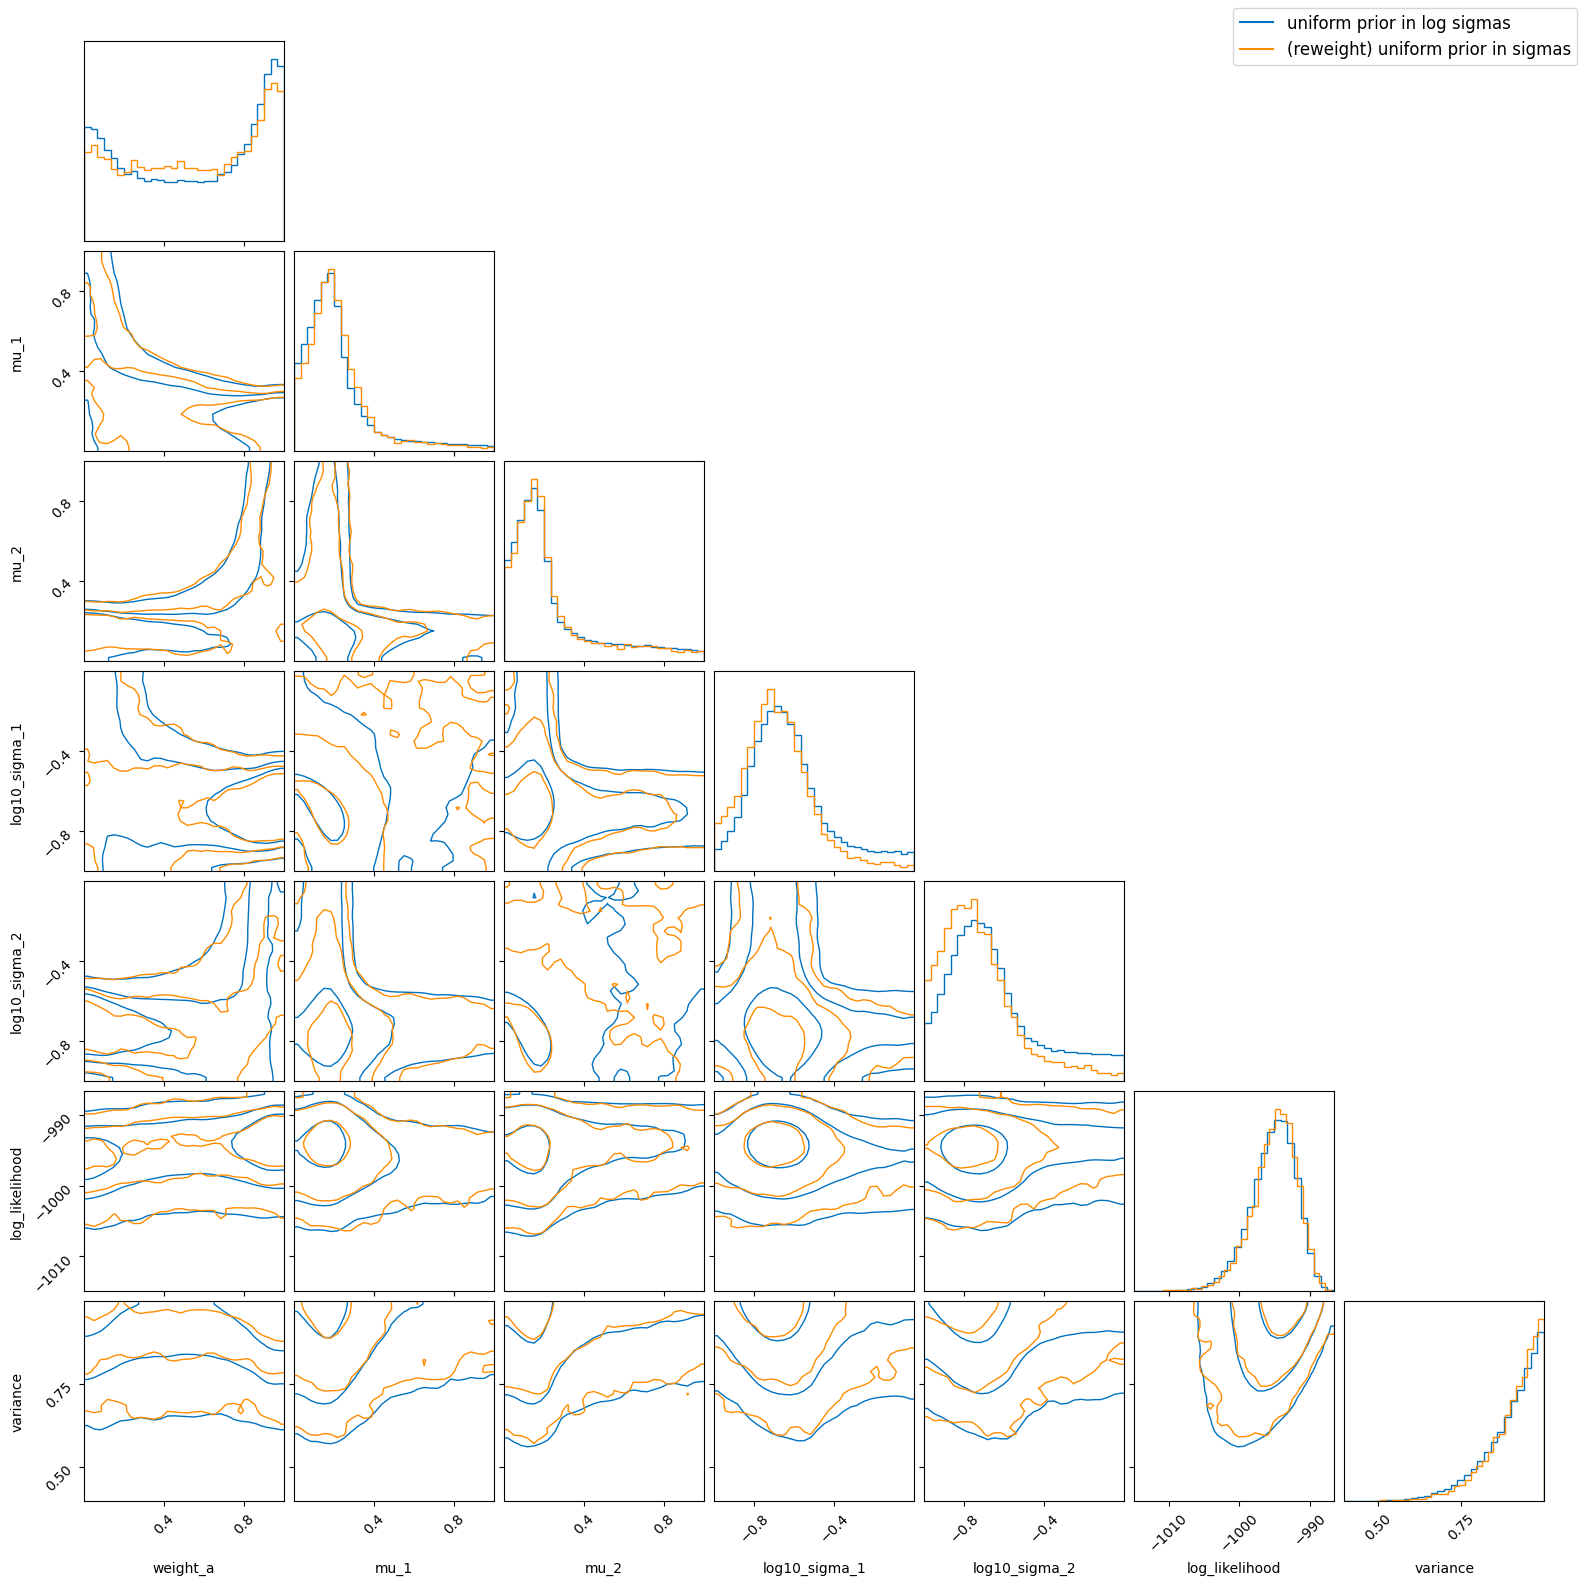

In [43]:
fig = plot_multiple(
    [unweighted_nlive10k, nlive10k],
    labels=['weight_a', 'mu_1', 'mu_2', 'log10_sigma_1', 'log10_sigma_2', 'log_likelihood', 'variance'],
    plot_datapoints=False,
    bins=30,
    fill_contours=False,
    no_fill_contours=True,
    xs_labels=['uniform prior in log sigmas', '(reweight) uniform prior in sigmas']
);

about to plot with: ['weight_a', 'mu_1', 'mu_2', 'log10_sigma_1', 'log10_sigma_2', 'log_likelihood', 'variance']
about to plot with: ['weight_a', 'mu_1', 'mu_2', 'log10_sigma_1', 'log10_sigma_2', 'log_likelihood', 'variance']
about to plot with: ['weight_a', 'mu_1', 'mu_2', 'log10_sigma_1', 'log10_sigma_2', 'log_likelihood', 'variance']


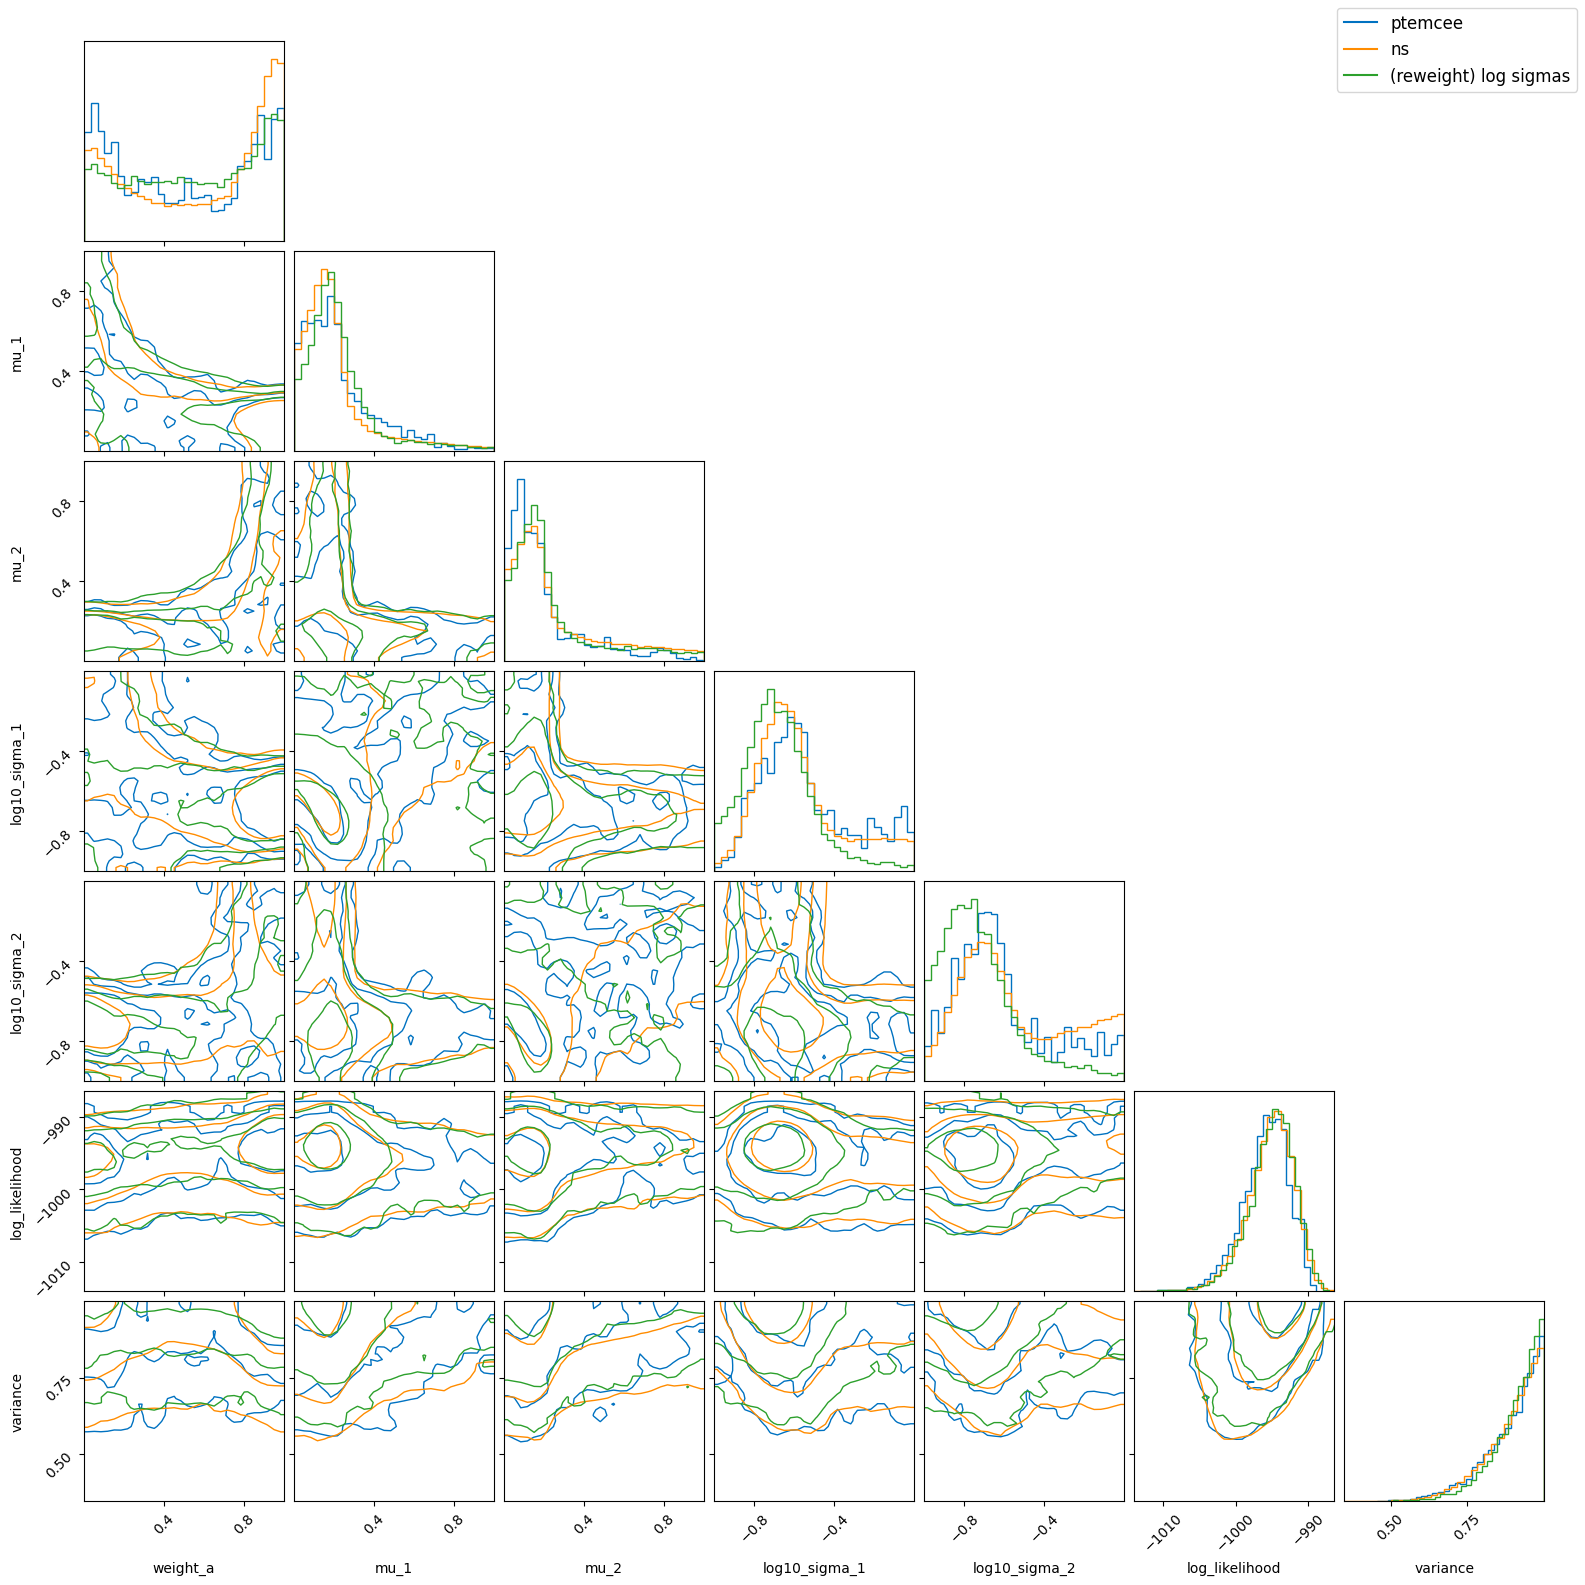

In [44]:
fig = plot_multiple(
    [r_pt, merged, nlive10k],
    labels=['weight_a', 'mu_1', 'mu_2', 'log10_sigma_1', 'log10_sigma_2', 'log_likelihood', 'variance'],
    plot_datapoints=False,
    bins=30,
    fill_contours=False,
    no_fill_contours=True,
    xs_labels=['ptemcee', 'ns', '(reweighted) log sigmas']
);

about to plot with: ['weight_a', 'mu_1', 'mu_2', 'log10_sigma_1', 'log10_sigma_2', 'log_likelihood', 'variance']
about to plot with: ['weight_a', 'mu_1', 'mu_2', 'log10_sigma_1', 'log10_sigma_2', 'log_likelihood', 'variance']


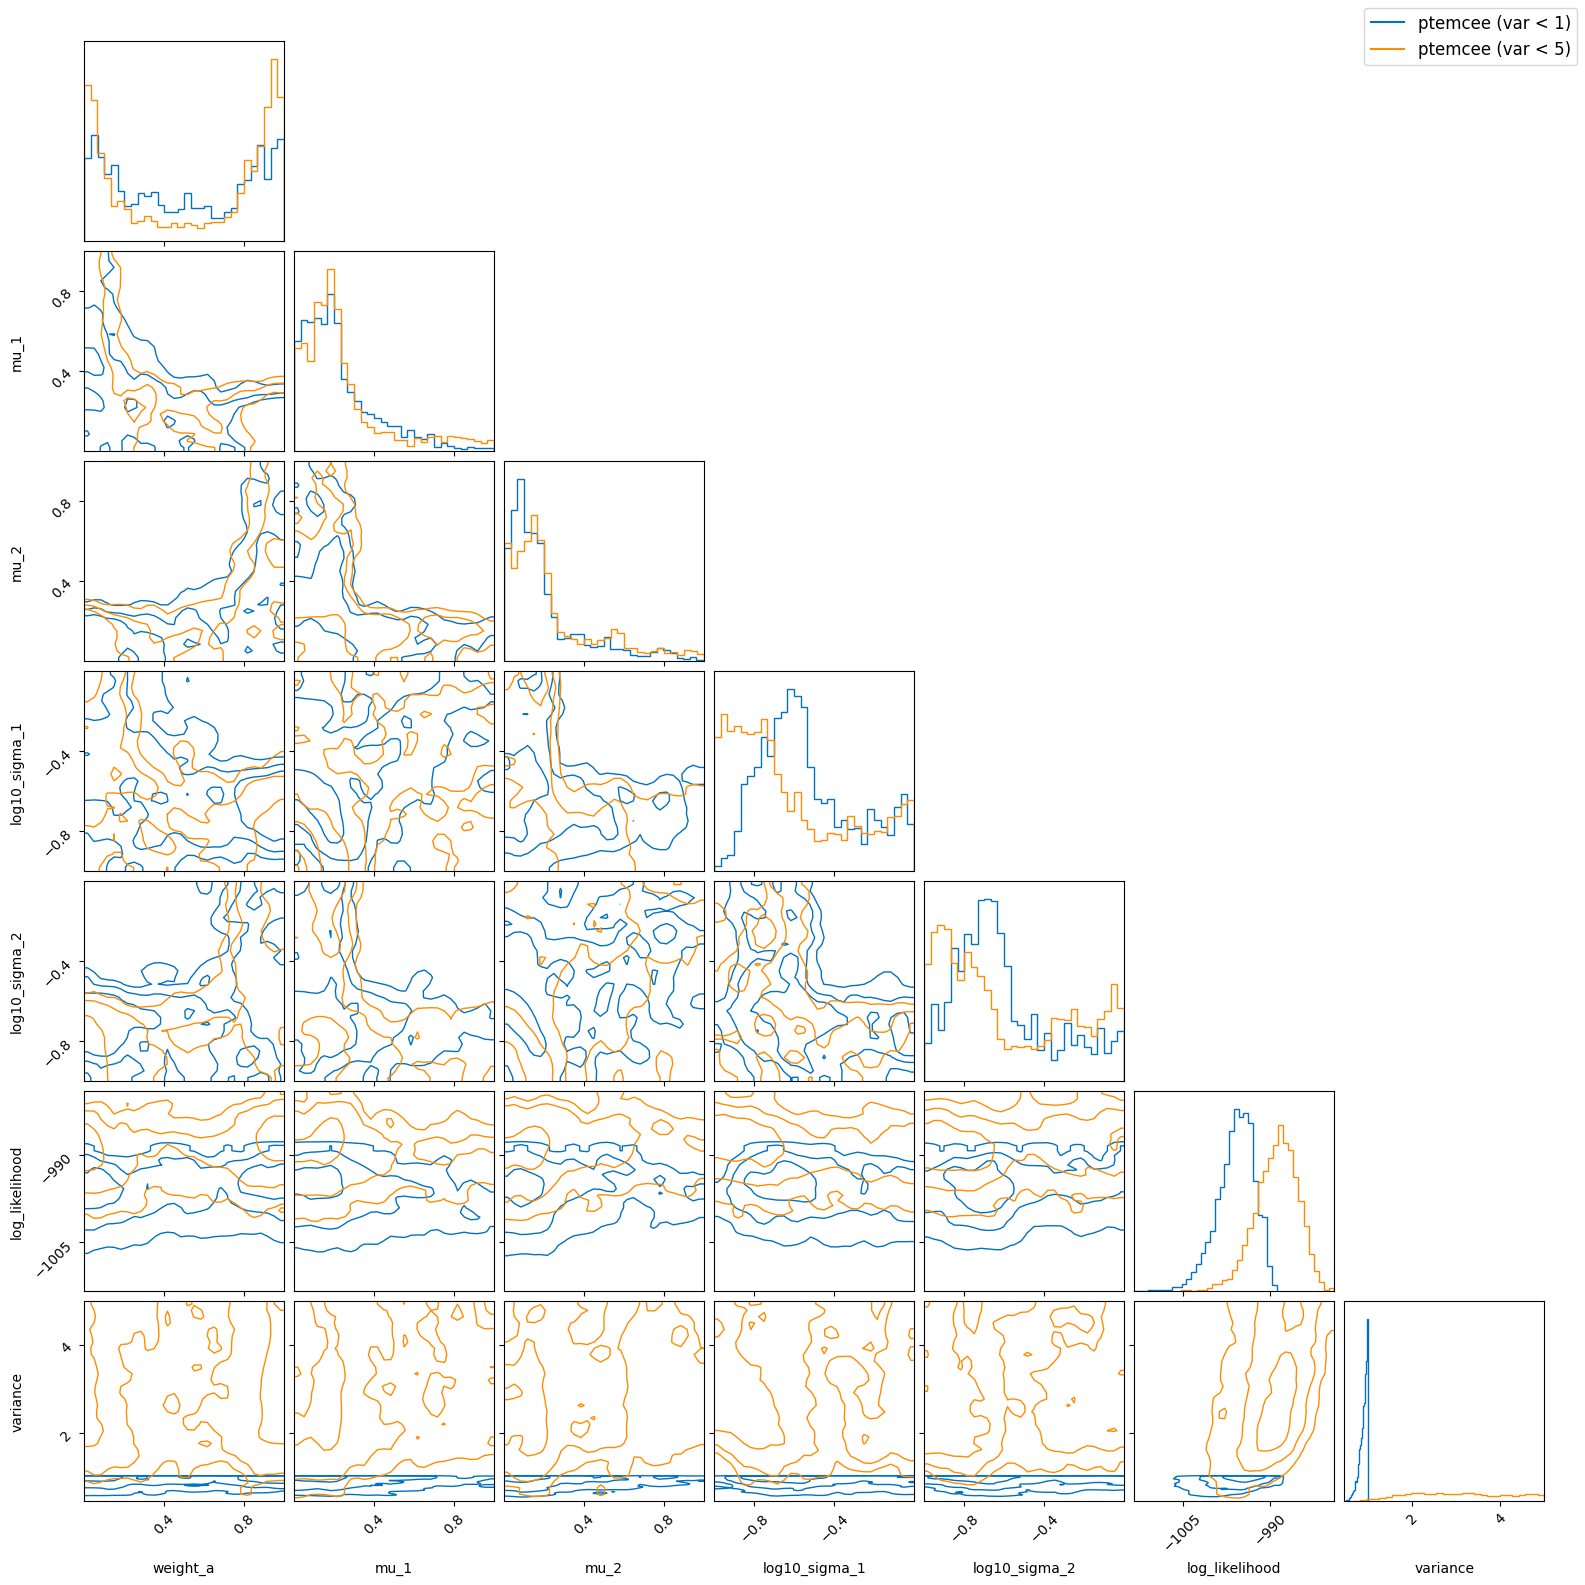

In [46]:
fig = plot_multiple(
    [r_pt, r_pt_5],
    labels=['weight_a', 'mu_1', 'mu_2', 'log10_sigma_1', 'log10_sigma_2', 'log_likelihood', 'variance'],
    plot_datapoints=False,
    bins=30,
    fill_contours=False,
    no_fill_contours=True,
    xs_labels=['ptemcee (var < 1)', 'ptemcee (var < 5)']
);

In [ ]:
bins = np.linspace(-1015, -980, 50)

fig, ax = plt.subplots()

mask1 = r_pt['weight_a'] < 0.2
mask2 = r_pt['weight_a'] > 0.8

ax.hist(
    r_pt['log_likelihood'][mask],
    histtype='step',
    bins=bins,
    density=True,
    label=r'$\xi < 0.2$, ptemcee',
    color='C0',
    linestyle='--'
)

mask = merged['weight_a'] < 0.2
ax.hist(
    merged['log_likelihood'][mask],
    histtype='step',
    bins=bins,
    density=True,
    label=r'$\xi < 0.2$, ns',
    color='C0'
)

mask = r_pt['weight_a'] > 0.8
ax.hist(
    r_pt['log_likelihood'][mask],
    histtype='step',
    bins=bins,
    density=True,
    label=r'$\xi > 0.8$, ptemcee',
    color='C1',
    linestyle='--'
)

mask = merged['weight_a'] > 0.8
ax.hist(
    merged['log_likelihood'][mask],
    histtype='step',
    bins=bins,
    density=True,
    label=r'$\xi > 0.8$, ns',
    color='C1',
)

ax.legend();
ax.set_xlabel(r'$\ln \hat{L}$');
ax.set_ylabel('density')

In [113]:
models = ['twomass', 'threemass']

bins = np.linspace(0, 1, 30)
ks = dict(histtype='step', bins=bins, density=True)

for model in models:
    modeldir = f'{datadir}/{model}'
    r_pt = h5ify.load(f'{modeldir}/ptemcee-hybrid-var1/posterior.h5')

    results = []
    for seed in range(1701, 1711):
        r = read_in_result(f'{modeldir}/sampling_seed/{seed}/run_result.hdf5')
        v = h5ify.load(f'{modeldir}/sampling_seed/{seed}/posterior.h5')['variance']
        r.posterior['variance'] = v
        results.append(r)

    _, merged = merge_runs(results, evidence_weight=True)
    merged = {k : np.array(v) for k, v in merged.to_dict(orient='list').items()}
    h5ify.save(f'{modeldir}/sampling_seed/merged.h5', merged, mode='w')

    continue
    
    fig, ax = plt.subplots()
    ax.hist(merged['weight_a'], label='10 merged runs', **ks);
    ax.hist(r_pt['weight_a'], label='hybrid ptemcee', **ks);

    for nlive in [10_000, 5_000, 2_500, 1_000]:
        if os.path.isfile(f'{modeldir}/log-sigma/var1/nlive/{nlive}/posterior.h5'):
            r_n = h5ify.load(f'{modeldir}/log-sigma/var1/nlive/{nlive}/posterior.h5')
            log_sigmas = np.stack([r_n[f'log_sigma_{i}'] for i in range(1, 4)])
            log_weights = -np.sum(log_sigmas, axis=0)

            for k in list(r_n['samples'].keys()):
                r_n['samples'].pop(k)

            for i in range(1, 4):
                r_n[f'sigma_{i}'] = np.exp(r_n[f'log_sigma_{i}'])
                r_n[f'log10_sigma_{i}'] = np.log10(r_n[f'sigma_{i}'])

            rng = np.random.default_rng(12413)
            weights = np.exp(log_weights)
            keep = weights > rng.uniform(0, max(weights), len(weights))

            for k, v in r_n.items():
                if len(np.atleast_1d(v)) > 1:
                    r_n[k] = v[keep]

            ax.hist(
                r_n['weight_a'],
                label=f'log-sigma with {nlive} live points',
                **ks
            )
            break

    ax.legend()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 6.2)
    ax.set_xlabel(r'$\xi$')
    ax.set_box_aspect(1)
    
    
    bins = np.linspace(-1015, -980, 50)

    fig, ax = plt.subplots()

    mask = r_pt['weight_a'] < 0.2
    ax.hist(
        r_pt['log_likelihood'][mask],
        histtype='step',
        bins=bins,
        density=True,
        label=r'$\xi < 0.2$, ptemcee',
        color='C0',
        linestyle='--'
    )

    mask = merged['weight_a'] < 0.2
    ax.hist(
        merged['log_likelihood'][mask],
        histtype='step',
        bins=bins,
        density=True,
        label=r'$\xi < 0.2$, ns',
        color='C0'
    )

    mask = r_pt['weight_a'] > 0.8
    ax.hist(
        r_pt['log_likelihood'][mask],
        histtype='step',
        bins=bins,
        density=True,
        label=r'$\xi > 0.8$, ptemcee',
        color='C1',
        linestyle='--'
    )

    mask = merged['weight_a'] > 0.8
    ax.hist(
        merged['log_likelihood'][mask],
        histtype='step',
        bins=bins,
        density=True,
        label=r'$\xi > 0.8$, ns',
        color='C1',
    )

    ax.legend();
    ax.set_xlabel(r'$\ln \hat{L}$');
    ax.set_ylabel('density')

about to plot with: ['weight_a', 'mu_1', 'mu_2', 'log10_sigma_1', 'log10_sigma_2', 'log_likelihood', 'variance']
about to plot with: ['weight_a', 'mu_1', 'mu_2', 'log10_sigma_1', 'log10_sigma_2', 'log_likelihood', 'variance']
about to plot with: ['weight_a', 'mu_1', 'mu_2', 'log10_sigma_1', 'log10_sigma_2', 'log_likelihood', 'variance']
about to plot with: ['weight_a', 'mu_1', 'mu_2', 'log10_sigma_1', 'log10_sigma_2', 'log_likelihood', 'variance']
about to plot with: ['weight_a', 'mu_1', 'mu_2', 'log10_sigma_1', 'log10_sigma_2', 'log_likelihood', 'variance']
about to plot with: ['weight_a', 'mu_1', 'mu_2', 'log10_sigma_1', 'log10_sigma_2', 'log_likelihood', 'variance']


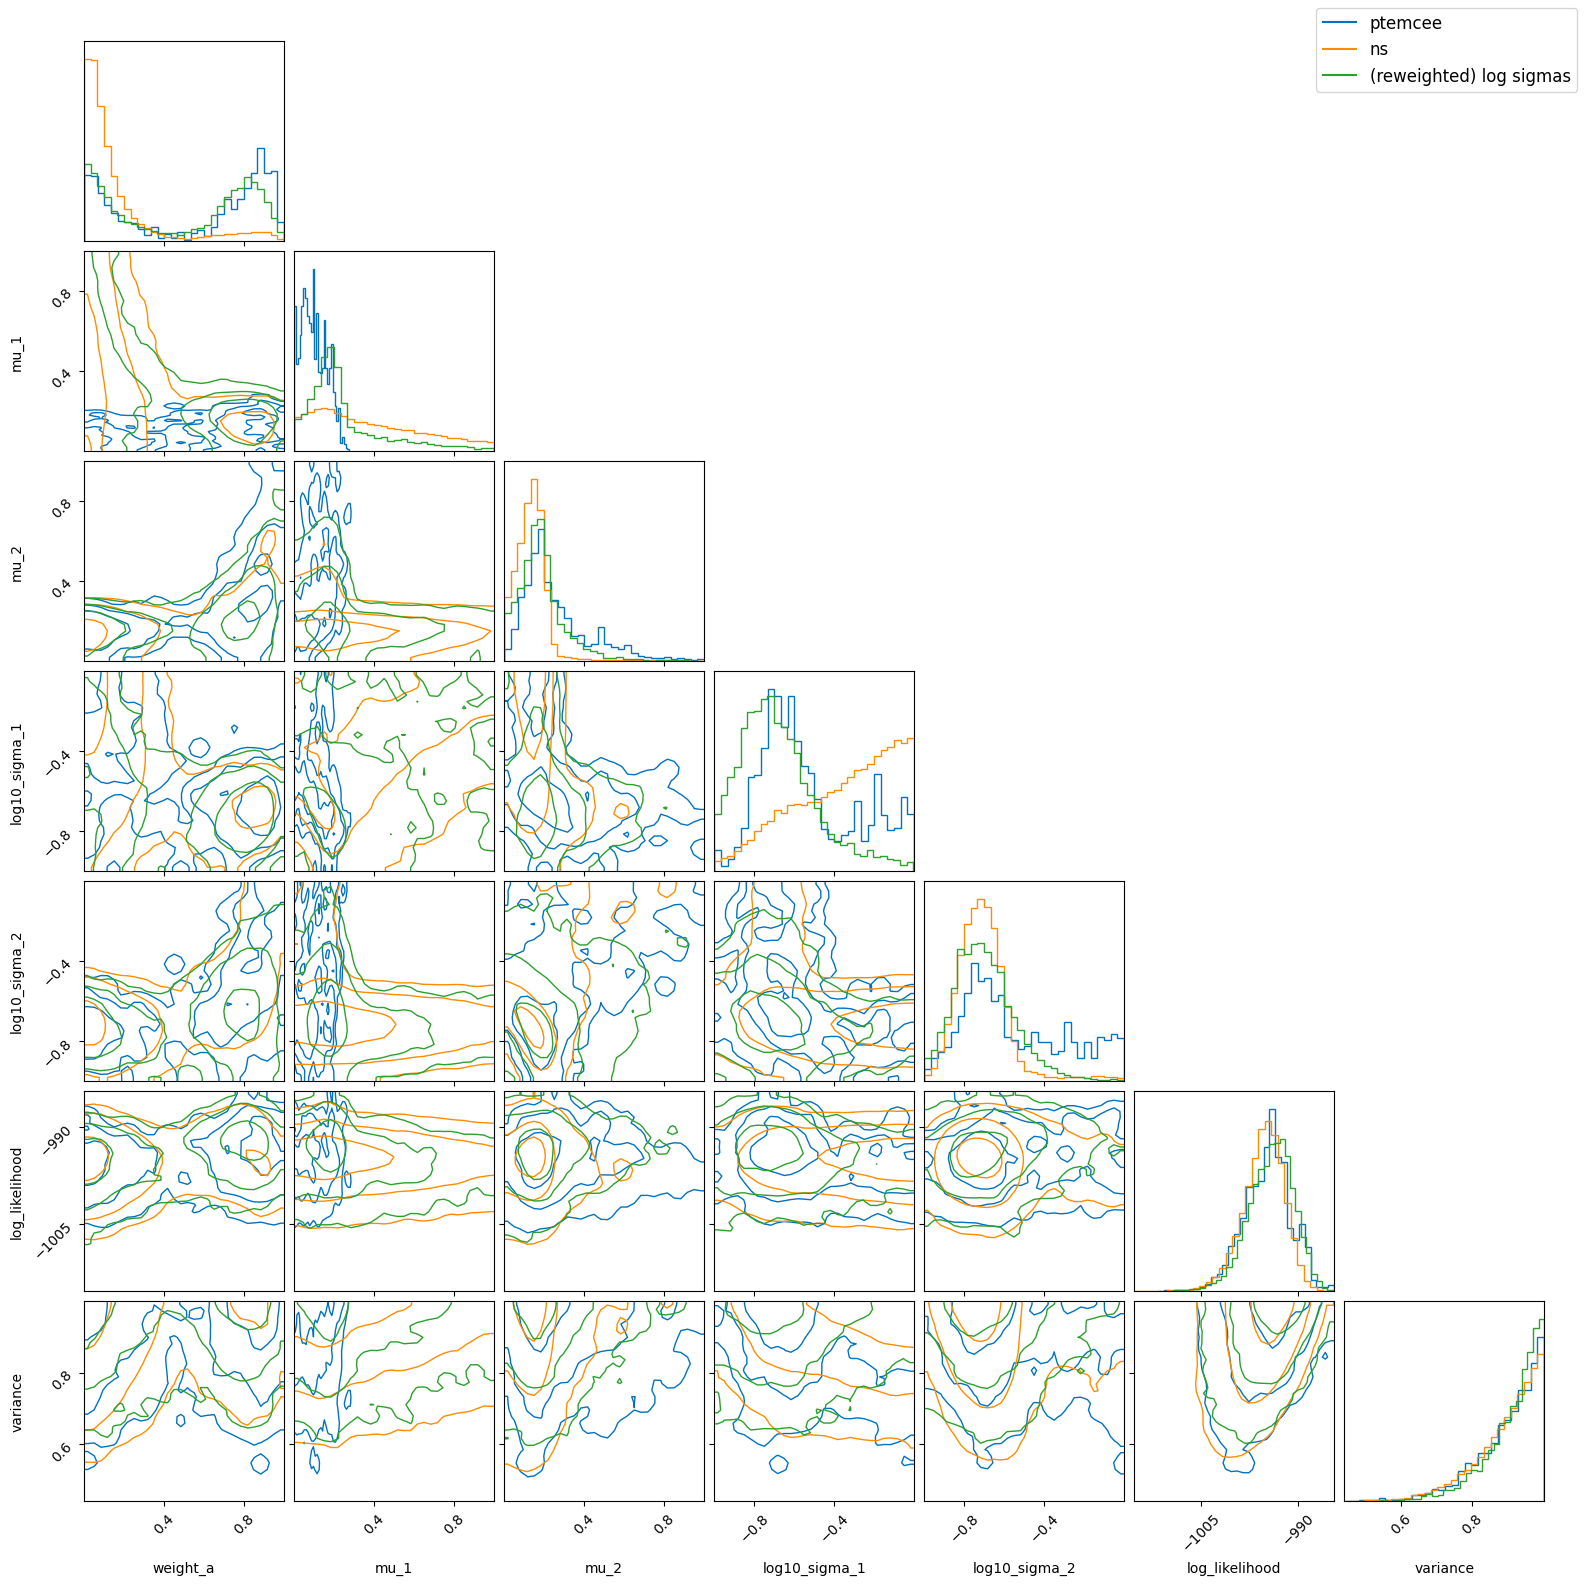

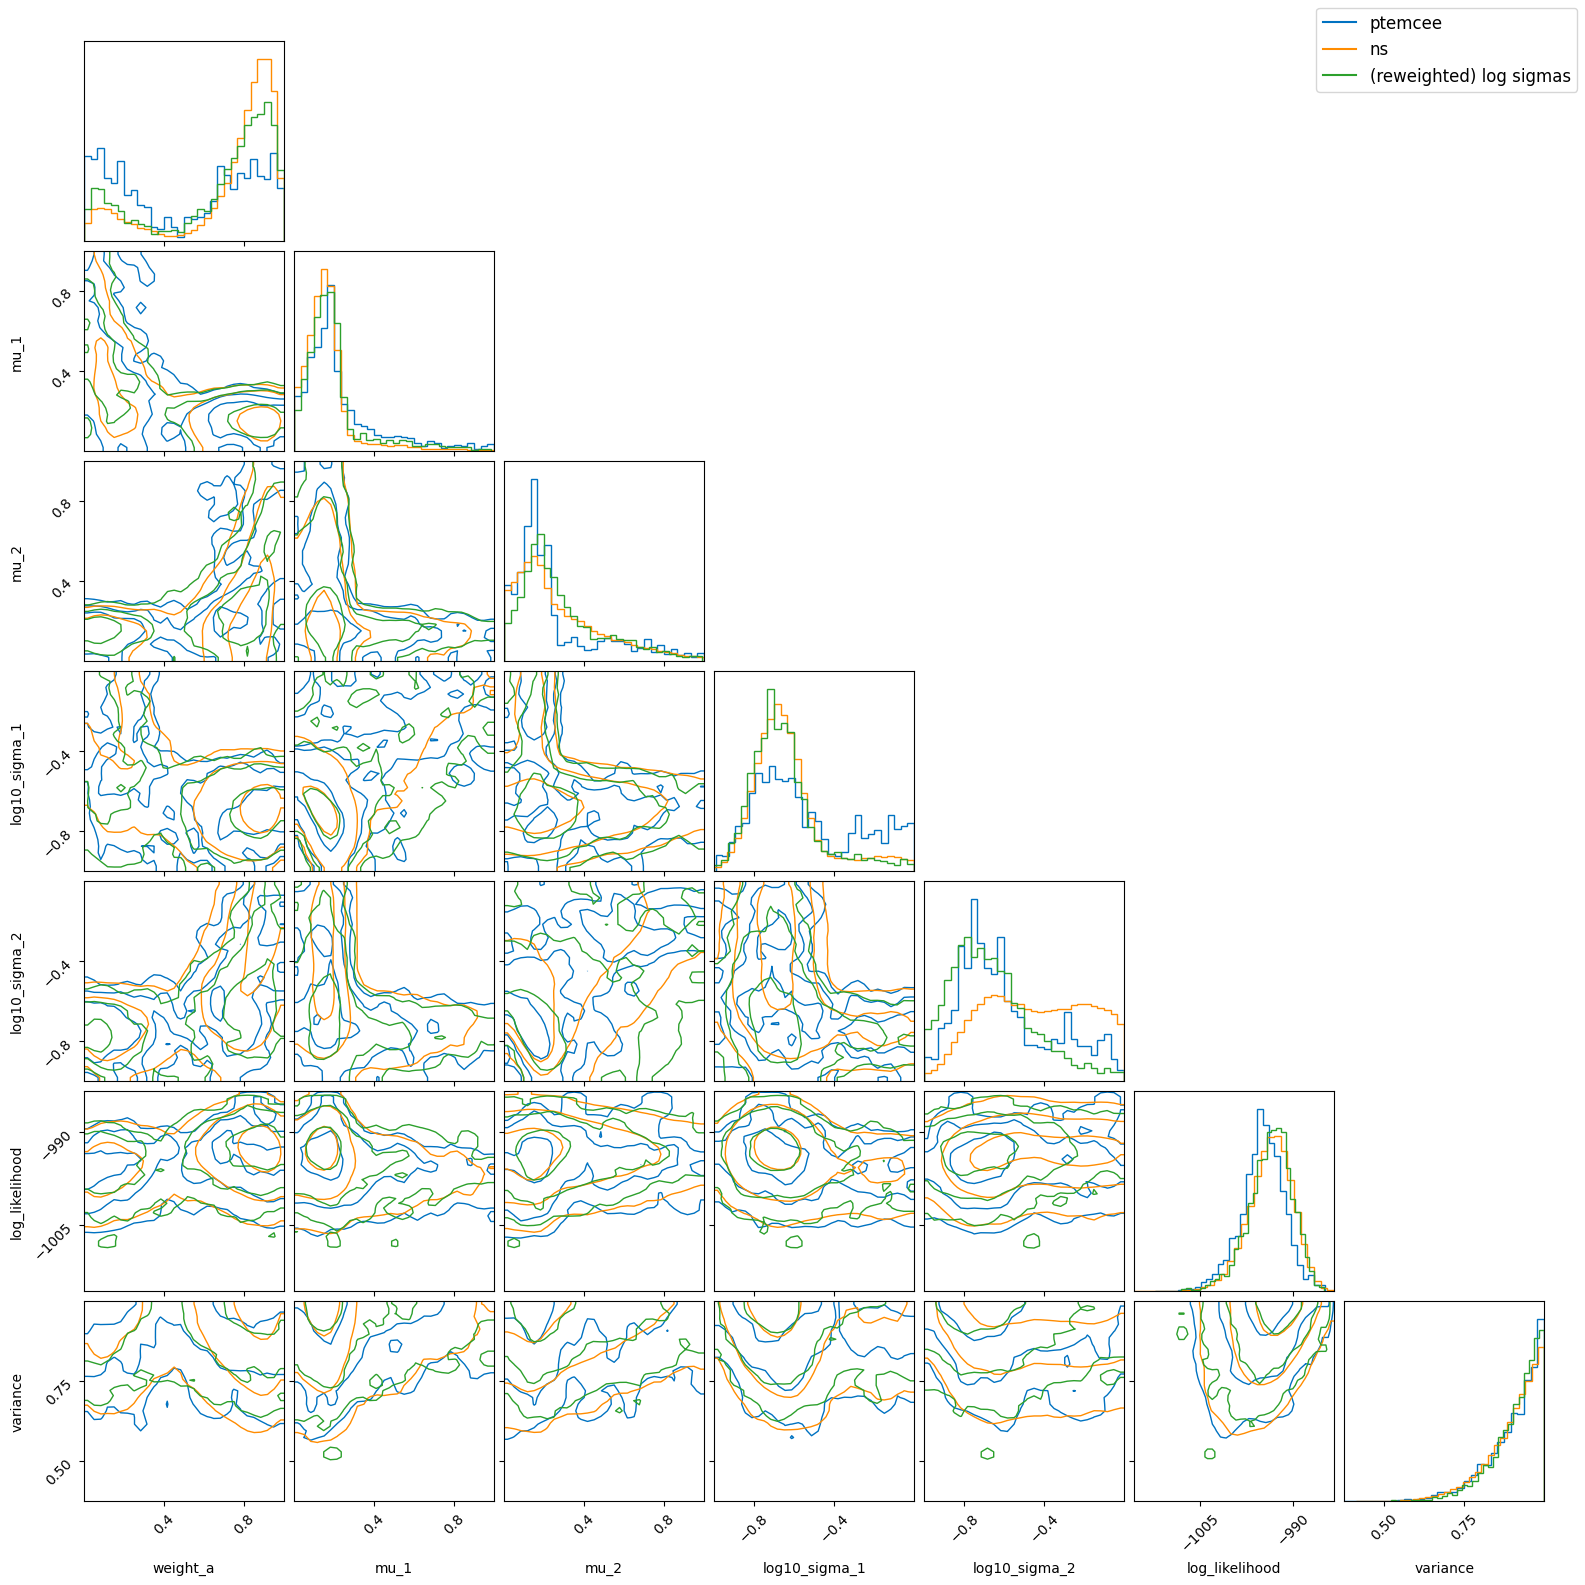

In [78]:
models = ['twomass', 'threemass']

bins = np.linspace(0, 1, 30)
ks = dict(histtype='step', bins=bins, density=True)

for model in models:
    modeldir = f'{datadir}/{model}'
    r_pt = h5ify.load(f'{modeldir}/ptemcee-hybrid-var1/posterior.h5')

    for k in list(r_pt['samples'].keys()):
        r_pt['samples'].pop(k)

    for i in range(1, 4):
        r_pt[f'log_sigma_{i}'] = np.log(r_pt[f'sigma_{i}'])
        r_pt[f'log10_sigma_{i}'] = np.log10(r_pt[f'sigma_{i}'])

    results = []
    for seed in range(1701, 1711):
        rundir = f'{modeldir}/sampling_seed/{seed}'
        r = read_in_result(f'{rundir}/run_result.hdf5')
        v = h5ify.load(f'{rundir}/posterior.h5')
        r.posterior['variance'] = v['variance']
        results.append(r)

    _, merged = merge_runs(results, evidence_weight=True)
    merged = {k : np.array(v) for k, v in merged.to_dict(orient='list').items()}

    for i in range(1, 4):
        merged[f'log_sigma_{i}'] = np.log(merged[f'sigma_{i}'])
        merged[f'log10_sigma_{i}'] = np.log10(merged[f'sigma_{i}'])

    for nlive in [10_000, 5_000, 2_500, 1_000]:
        if os.path.isfile(f'{modeldir}/log-sigma/var1/nlive/{nlive}/posterior.h5'):
            r_n = h5ify.load(f'{modeldir}/log-sigma/var1/nlive/{nlive}/posterior.h5')
            log_sigmas = np.stack([r_n[f'log_sigma_{i}'] for i in range(1, 4)])
            log_weights = -np.sum(log_sigmas, axis=0)

            for k in list(r_n['samples'].keys()):
                r_n['samples'].pop(k)

            for i in range(1, 4):
                r_n[f'sigma_{i}'] = np.exp(r_n[f'log_sigma_{i}'])
                r_n[f'log10_sigma_{i}'] = np.log10(r_n[f'sigma_{i}'])

            rng = np.random.default_rng(12413)
            weights = np.exp(log_weights)
            keep = weights > rng.uniform(0, max(weights), len(weights))

            for k, v in r_n.items():
                if len(np.atleast_1d(v)) > 1:
                    r_n[k] = v[keep]

            break

    fig = plot_multiple(
        [r_pt, merged, r_n],
        labels=['weight_a', 'mu_1', 'mu_2', 'log10_sigma_1', 'log10_sigma_2', 'log_likelihood', 'variance'],
        plot_datapoints=False,
        bins=30,
        fill_contours=False,
        no_fill_contours=True,
        xs_labels=['ptemcee', 'ns', '(reweighted) log sigmas']
    )

In [10]:
from popsummary.popresult import PopulationResult

rpdir = '/home/submit/newolfe/lvk-data/GWTC-4/RP'

r = PopulationResult(f'{rpdir}/BBHSpin_GaussianChiEffChiP.h5')
grid_gauss_chieff, rates = r.get_rates_on_grids('chi_eff')

med_gauss_chieff = np.median(rates, axis=0)
cil_gauss_chieff = np.quantile(rates, 0.05, axis=0)
ciu_gauss_chieff = np.quantile(rates, 0.95, axis=0)

cill_gauss_chieff = np.quantile(rates, 0.005, axis=0)
ciuu_gauss_chieff = np.quantile(rates, 0.995, axis=0)

#gauss_chieff_mean = dict(zip(r.get_metadata('hyperparameters'), r.get_hyperparameter_samples().T))['mu_eff']
#gauss_chieff_mean = r.get_hyperparameter_samples(hyperparameters=['mu_chieff'])

opening existing popsummary file: /home/submit/newolfe/lvk-data/GWTC-4/RP/BBHSpin_GaussianChiEffChiP.h5


## onemass

In [27]:
clabels = ['low-mass, t.n.', 'low-mass, iso.', 'high-mass, iso.']

In [11]:
ppd = h5ify.load(
    '../../data/inference/strong/multimass/noah/bpl2p/sampling_seed/ppds.h5'
)

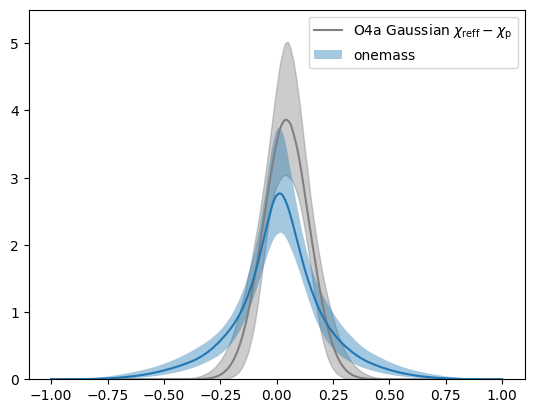

In [ ]:
fig, ax = plt.subplots()

ax.plot(
    grid_gauss_chieff.squeeze(),
    med_gauss_chieff,
    color='grey',
    label=r'O4a Gaussian $\chi_\mathrm{reff} - \chi_\mathrm{p}$'
)

ax.fill_between(
    grid_gauss_chieff.squeeze(),
    cil_gauss_chieff,
    ciu_gauss_chieff,
    alpha=0.4,
    color='grey'
)

#ax.plot(
#    ppd['xs']['chi_eff'],
#    ppd['medians']['chi_eff']
#)

xs = ppd['xs']['chi_eff']

ax.fill_between(
    xs,
    ppd['q05']['chi_eff'],
    ppd['q95']['chi_eff'],
    alpha=0.4,
    label='onemass'
)

ax.plot(
    ppd['xs']['chi_eff'],
    ppd['medians']['chi_eff']
)

ax.set_ylim(0, 5.5)

ax.legend();

Text(0.5, 0, '$m_1$ [$\\mathrm{M}_\\odot$]')

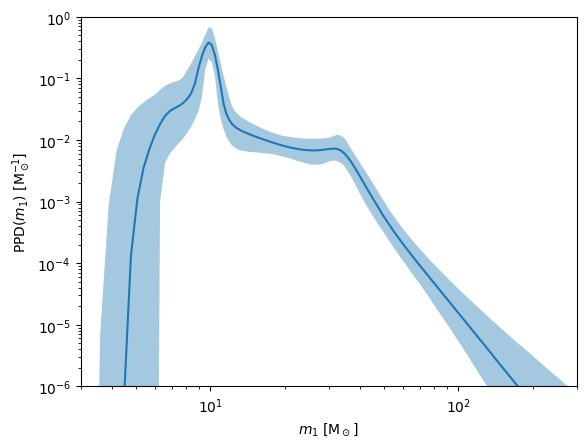

In [25]:
fig, ax = plt.subplots()

xs = ppd['xs']['mass_1']

ax.fill_between(
    xs,
    ppd['q05'][f'mass_1'],
    ppd['q95'][f'mass_1'],
    alpha=0.4
)

ax.plot(
    xs,
    ppd['medians'][f'mass_1']
);

ax.set_xlim(3, 300)
ax.set_ylim(1e-6, 1e0)
ax.loglog()

ax.set_ylabel(r'$\mathrm{PPD}(m_1)$ [$\mathrm{M}_\odot^{-1}$]')
ax.set_xlabel(r'$m_1$ [$\mathrm{M}_\odot$]')

Text(0, 0.5, '$\\mathrm{PPD}(q)$')

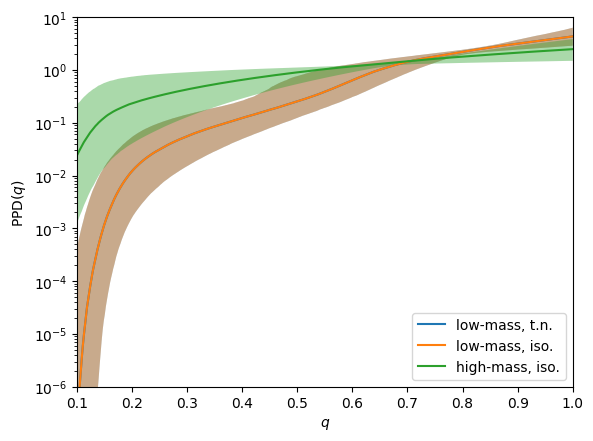

In [29]:
fig, ax = plt.subplots()

xs = ppd['xs']['mass_ratio']

for i in range(1, 4):
    
    label = clabels[i - 1]

    ax.fill_between(
        xs,
        ppd['q05'][f'mass_ratio_c{i}'],
        ppd['q95'][f'mass_ratio_c{i}'],
        alpha=0.4
    )

    ax.plot(
        xs,
        ppd['medians'][f'mass_ratio_c{i}'],
        label=label
    );

ax.legend();    

ax.set_xlim(0.1, 1)
ax.set_ylim(1e-6, 1e1)
ax.semilogy()

ax.set_xlabel(r'$q$')
ax.set_ylabel(r'$\mathrm{PPD}(q)$')

## twomass

In [30]:
ppd = h5ify.load(
    '../../data/inference/strong/multimass/noah/twomass/sampling_seed/ppds.h5'
)

In [39]:
post = h5ify.load(
    '../../data/inference/strong/multimass/noah/twomass/sampling_seed/merged.h5'
)

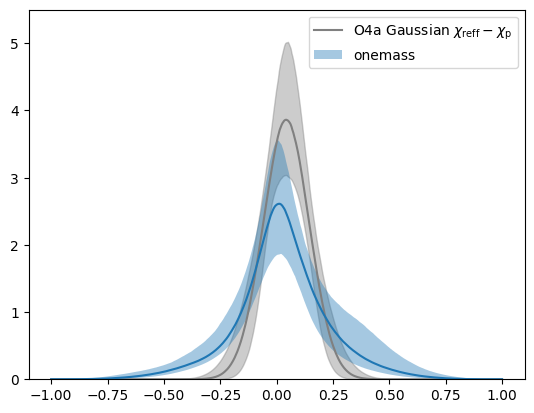

In [31]:
fig, ax = plt.subplots()

ax.plot(
    grid_gauss_chieff.squeeze(),
    med_gauss_chieff,
    color='grey',
    label=r'O4a Gaussian $\chi_\mathrm{reff} - \chi_\mathrm{p}$'
)

ax.fill_between(
    grid_gauss_chieff.squeeze(),
    cil_gauss_chieff,
    ciu_gauss_chieff,
    alpha=0.4,
    color='grey'
)

#ax.plot(
#    ppd['xs']['chi_eff'],
#    ppd['medians']['chi_eff']
#)

xs = ppd['xs']['chi_eff']

ax.fill_between(
    xs,
    ppd['q05']['chi_eff'],
    ppd['q95']['chi_eff'],
    alpha=0.4,
    label='onemass'
)

ax.plot(
    ppd['xs']['chi_eff'],
    ppd['medians']['chi_eff']
)

ax.set_ylim(0, 5.5)

ax.legend();

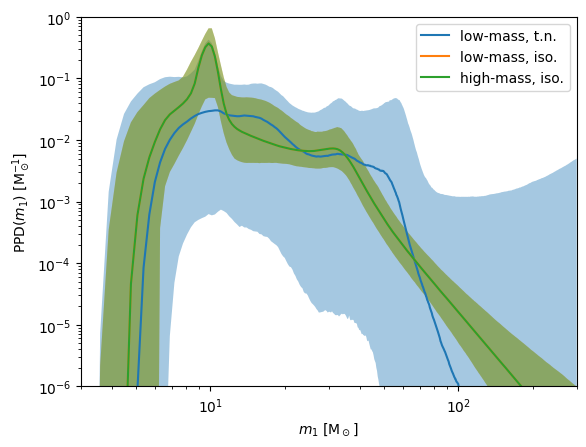

In [32]:
fig, ax = plt.subplots()

xs = ppd['xs']['mass_1']

for i in range(1, 4):

    label = clabels[i - 1]
    
    ax.fill_between(
        xs,
        ppd['q05'][f'mass_1_c{i}'],
        ppd['q95'][f'mass_1_c{i}'],
        alpha=0.4
    )

    ax.plot(
        xs,
        ppd['medians'][f'mass_1_c{i}'],
        label=label
    );

ax.legend()
ax.set_xlim(3, 300)
ax.set_ylim(1e-6, 1e0)
ax.loglog()

ax.set_ylabel(r'$\mathrm{PPD}(m_1)$ [$\mathrm{M}_\odot^{-1}$]')
ax.set_xlabel(r'$m_1$ [$\mathrm{M}_\odot$]');

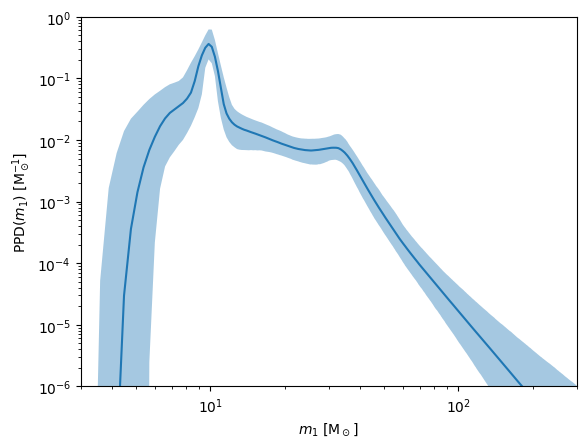

In [34]:
fig, ax = plt.subplots()

xs = ppd['xs']['mass_1']

ax.fill_between(
    xs,
    ppd['q05'][f'mass_1'],
    ppd['q95'][f'mass_1'],
    alpha=0.4
)

ax.plot(
    xs,
    ppd['medians'][f'mass_1']
);

ax.set_xlim(3, 300)
ax.set_ylim(1e-6, 1e0)
ax.loglog()

ax.set_ylabel(r'$\mathrm{PPD}(m_1)$ [$\mathrm{M}_\odot^{-1}$]')
ax.set_xlabel(r'$m_1$ [$\mathrm{M}_\odot$]');

Text(0, 0.5, '$\\mathrm{PPD}(q)$')

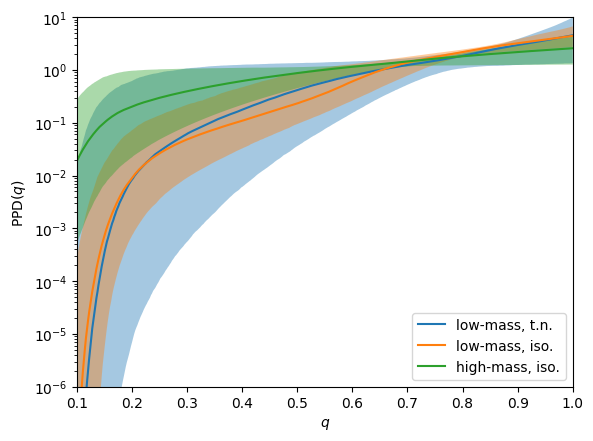

In [35]:
fig, ax = plt.subplots()

xs = ppd['xs']['mass_ratio']

for i in range(1, 4):
    
    label = clabels[i - 1]

    ax.fill_between(
        xs,
        ppd['q05'][f'mass_ratio_c{i}'],
        ppd['q95'][f'mass_ratio_c{i}'],
        alpha=0.4
    )

    ax.plot(
        xs,
        ppd['medians'][f'mass_ratio_c{i}'],
        label=label
    );

ax.legend();    

ax.set_xlim(0.1, 1)
ax.set_ylim(1e-6, 1e1)
ax.semilogy()

ax.set_xlabel(r'$q$')
ax.set_ylabel(r'$\mathrm{PPD}(q)$')

## threemass

In [44]:
ppd = h5ify.load(
    '../../data/inference/strong/multimass/noah/threemass/sampling_seed/ppds.h5'
)

In [45]:
post = h5ify.load(
    '../../data/inference/strong/multimass/noah/threemass/sampling_seed/merged.h5'
)

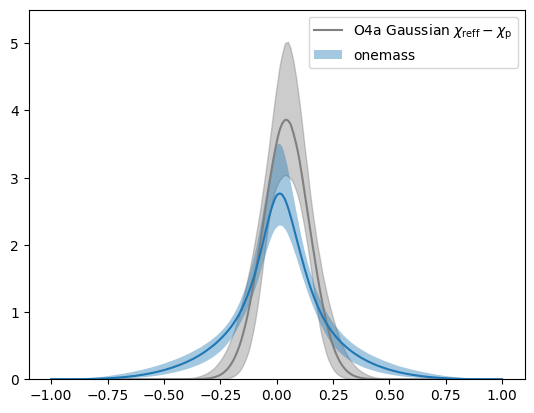

In [46]:
fig, ax = plt.subplots()

ax.plot(
    grid_gauss_chieff.squeeze(),
    med_gauss_chieff,
    color='grey',
    label=r'O4a Gaussian $\chi_\mathrm{reff} - \chi_\mathrm{p}$'
)

ax.fill_between(
    grid_gauss_chieff.squeeze(),
    cil_gauss_chieff,
    ciu_gauss_chieff,
    alpha=0.4,
    color='grey'
)

#ax.plot(
#    ppd['xs']['chi_eff'],
#    ppd['medians']['chi_eff']
#)

xs = ppd['xs']['chi_eff']

ax.fill_between(
    xs,
    ppd['q05']['chi_eff'],
    ppd['q95']['chi_eff'],
    alpha=0.4,
    label='onemass'
)

ax.plot(
    ppd['xs']['chi_eff'],
    ppd['medians']['chi_eff']
)

ax.set_ylim(0, 5.5)

ax.legend();

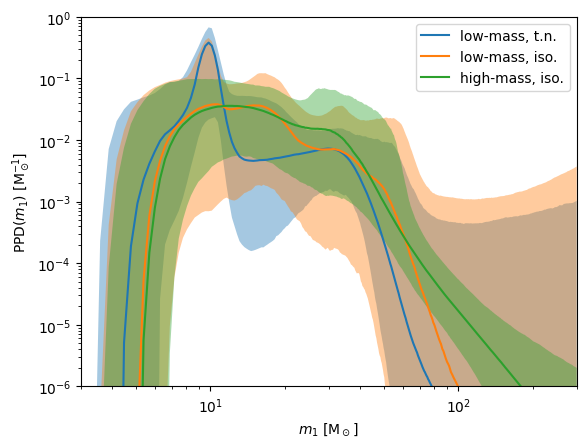

In [47]:
fig, ax = plt.subplots()

xs = ppd['xs']['mass_1']

for i in range(1, 4):

    label = clabels[i - 1]
    
    ax.fill_between(
        xs,
        ppd['q05'][f'mass_1_c{i}'],
        ppd['q95'][f'mass_1_c{i}'],
        alpha=0.4
    )

    ax.plot(
        xs,
        ppd['medians'][f'mass_1_c{i}'],
        label=label
    );

ax.legend()
ax.set_xlim(3, 300)
ax.set_ylim(1e-6, 1e0)
ax.loglog()

ax.set_ylabel(r'$\mathrm{PPD}(m_1)$ [$\mathrm{M}_\odot^{-1}$]')
ax.set_xlabel(r'$m_1$ [$\mathrm{M}_\odot$]');

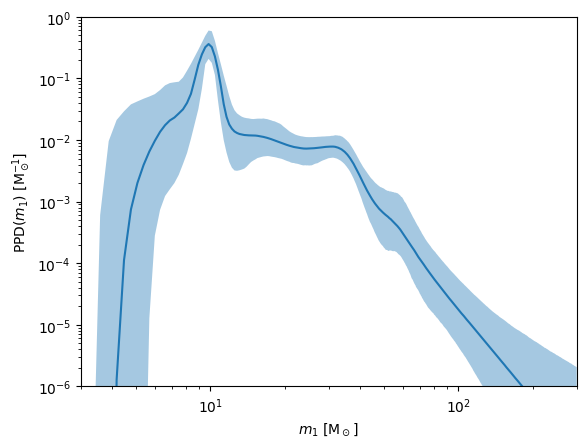

In [49]:
fig, ax = plt.subplots()

xs = ppd['xs']['mass_1']

ax.fill_between(
    xs,
    ppd['q05'][f'mass_1'],
    ppd['q95'][f'mass_1'],
    alpha=0.4
)

ax.plot(
    xs,
    ppd['medians'][f'mass_1']
);

ax.set_xlim(3, 300)
ax.set_ylim(1e-6, 1e0)
ax.loglog()

ax.set_ylabel(r'$\mathrm{PPD}(m_1)$ [$\mathrm{M}_\odot^{-1}$]')
ax.set_xlabel(r'$m_1$ [$\mathrm{M}_\odot$]');

Text(0, 0.5, '$\\mathrm{PPD}(q)$')

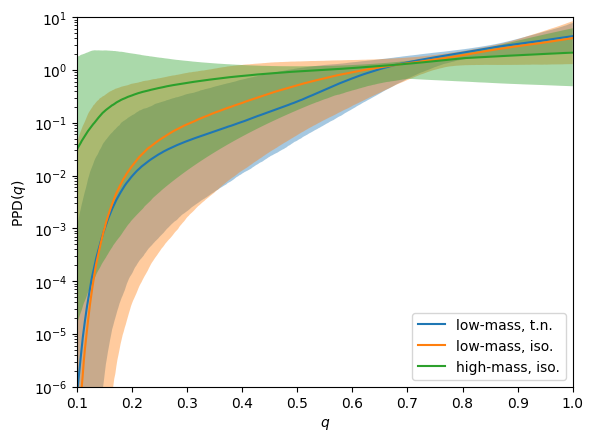

In [50]:
fig, ax = plt.subplots()

xs = ppd['xs']['mass_ratio']

for i in range(1, 4):
    
    label = clabels[i - 1]

    ax.fill_between(
        xs,
        ppd['q05'][f'mass_ratio_c{i}'],
        ppd['q95'][f'mass_ratio_c{i}'],
        alpha=0.4
    )

    ax.plot(
        xs,
        ppd['medians'][f'mass_ratio_c{i}'],
        label=label
    );

ax.legend();    

ax.set_xlim(0.1, 1)
ax.set_ylim(1e-6, 1e1)
ax.semilogy()

ax.set_xlabel(r'$q$')
ax.set_ylabel(r'$\mathrm{PPD}(q)$')